<p style="font-family:Nazanin; font-size:140%; text-align:center;" dir="rtl">
   «تحلیل داده‌ آگهی‌های دیوار»
</p>

In [ ]:
#!py -3.12 -m pip install geopy
#!py -3.12 -m pip install requests
#!py -3.12 -m pip install time

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری کتابخانه های مورد نیاز
</p>

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری داده های مورد نیاز
</p>

In [45]:
#data = pd.read_csv('/content/divar_real_estate_ads.csv', encoding="utf-8")
data = pd.read_csv('sampled_data.csv',encoding = 'utf-8', engine='python')

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
تابع مورد نیاز برای پاکسازی داده ها
</p>

<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش اول : بررسی کیفیت داده
</p>
<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید .
</p>

In [46]:
df_na = data.isna().sum().reset_index()
df_na.columns = ["column", "missing_nums"]
df_na["percent_missing"] = (df_na["missing_nums"] / len(data)) * 100
# sort columns from lowest number of NA's to the highest
df_na = df_na.sort_values(by="percent_missing", ascending=True)
print("columns with lowest number of NA's")
print(df_na.head(5))
print("\n")
print("columns with highest number of NA's")
print((df_na.tail(20)))
data['deed_type'].value_counts()

columns with lowest number of NA's
             column  missing_nums  percent_missing
0         cat2_slug             0              0.0
1         cat3_slug             0              0.0
2         city_slug             0              0.0
4  created_at_month             0              0.0
6       description             0              0.0


columns with highest number of NA's
                        column  missing_nums  percent_missing
11                   rent_type        134506        89.670667
21            transformed_rent        139186        92.790667
19          transformed_credit        139186        92.790667
25           has_business_deed        144786        96.524000
39                     has_gas        145008        96.672000
36                   has_water        145009        96.672667
38             has_electricity        145011        96.674000
43          has_security_guard        145355        96.903333
44                has_barbecue        145380        96.920000
5

deed_type
single_page          29269
written_agreement     4785
other                 3098
multi_page            1014
unselect                85
Name: count, dtype: int64

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. آیا ردیف‌های تکراری در داده وجود دارد؟
</p>

In [47]:
print('number of duplicated rows: ',data.duplicated(keep = 'last').sum())


number of duplicated rows:  0


<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش دوم : تحلیل اکتشافی داده (EDA)
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. توزیع و مشخصه‌های آماری هر یک از ستون‌ها (متغیرهای عددی) را ترسیم و بررسی کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. ارتباط دو به دوی تعدادی از متغیرها را که تصور می‌کنید به فهم داده کمک می‌کنند، بررسی کنید.
</p>

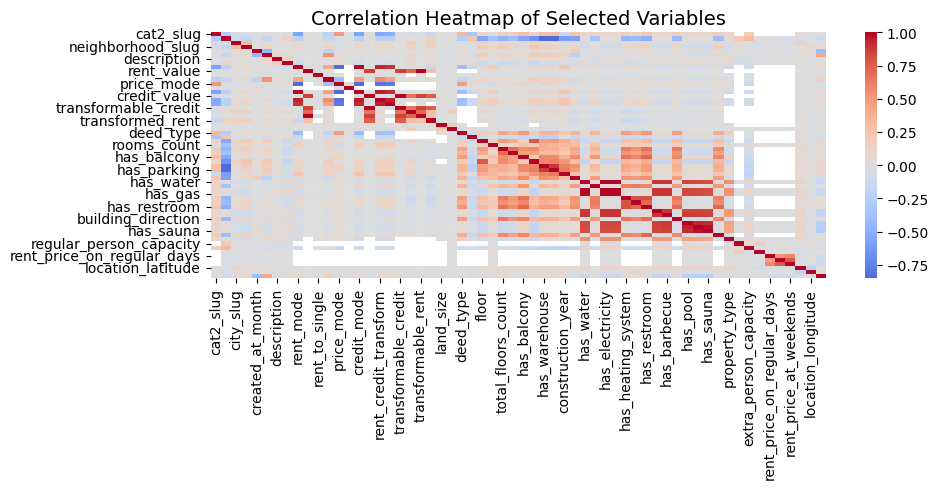

Pairs of columns with absolute correlation > 0.8:
there is strong negative correlation between price_mode - rent_mode: -0.840 

there is strong positive correlation between credit_mode - rent_mode: 0.985 

there is strong negative correlation between credit_mode - price_mode: -0.852 

there is strong positive correlation between credit_value - rent_value: 0.849 

there is strong positive correlation between rent_credit_transform - rent_mode: 0.939 

there is strong negative correlation between rent_credit_transform - price_mode: -0.816 

there is strong positive correlation between rent_credit_transform - credit_mode: 0.955 

there is strong positive correlation between transformable_price - rent_mode: 0.905 

there is strong positive correlation between transformable_price - credit_mode: 0.923 

there is strong positive correlation between transformable_price - rent_credit_transform: 0.945 

there is strong positive correlation between transformable_credit - rent_value: 0.849 

there 

In [48]:

data_clean = data.copy()

# Convert booleans-like strings to numeric 1/0
bool_cols = [c for c in data_clean.columns if data_clean[c].dtype == 'object' and
             set(data_clean[c].dropna().unique()).issubset({'TRUE', 'FALSE', 'True', 'False','true','false'})]

for col in bool_cols:
    data_clean[col] = data_clean[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

# Convert categorical columns to category codes
for col in data_clean.columns:
    if data_clean[col].dtype == 'object':
        data_clean[col] = data_clean[col].astype('category').cat.codes


#save this dataframe for later process
#data_clean.to_csv('divar_clean.csv',index = False)

corr_matrix = data_clean.corr(numeric_only=True)

# Visualize correlations (heatmap)
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Selected Variables', fontsize=14)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)
plt.show()

#findout the correlation between values in corr_matrix
high_corr_pairs = []
# Iterate through the correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i): # Start from j=0 to avoid duplicate pairs and the diagonal
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            correlation_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, correlation_value))

# Print the pairs
print("Pairs of columns with absolute correlation > 0.8:")
for pair in high_corr_pairs:
    if pair[2] > 0 :
      print(f"there is strong positive correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")
    else:
      print(f"there is strong negative correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. نکات قابل توجهی را که از بررسی توزیع‌ها و نمودارهای پراکندگی و مقدار همبستگی دریافتید فهرست کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.
</p>

# from here  ....

In [4]:
#calculate price per square meter and rent per square meter
data2 = data.copy()
data2['price_per_meter'] = (data2['price_value'] / data2['building_size'])/1000000

#since we have credit and rent price we need total rent
data2['total_rent'] = data2['rent_value']*30 + data2['credit_value']
data2['rent_price_per_meter'] = (data2['total_rent'] / data2['building_size'])/1000000


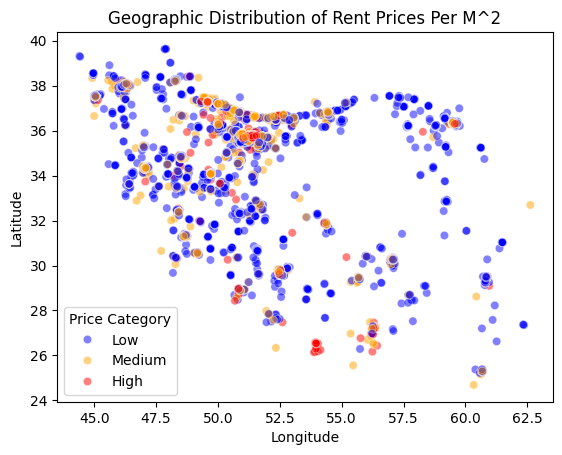

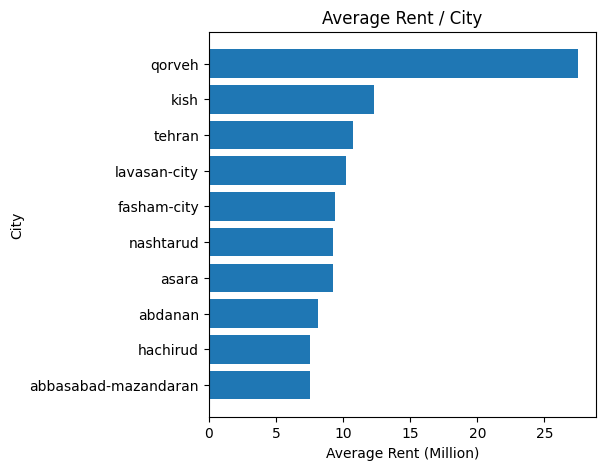

In [36]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['total_rent'].quantile(0.25)
Q3 = data2['total_rent'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data4 = data2[(data2['cat2_slug']=='residential-rent') &
              (data2['cat3_slug']=='apartment-rent') &
              (data2['total_rent'] > lower_bound) &
              (data2['total_rent'] < upper_bound)]

bins = [data4['rent_price_per_meter'].min()-1, data4['rent_price_per_meter'].quantile(0.33),
       data4['rent_price_per_meter'].quantile(0.66), data4['rent_price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data4['price_category'] = pd.cut(data4['rent_price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data4,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Rent Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()

avg_rent_per_city = data4.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_city = avg_rent_per_city.sort_values('rent_price_per_meter', ascending=False)
avg_rent_per_city[avg_rent_per_city['rent_price_per_meter'].notnull()]
avg_rent_per_city = avg_rent_per_city.head(10)
plt.figure(figsize = (5, 5))

plt.barh(
    avg_rent_per_city['city_slug'],
    avg_rent_per_city['rent_price_per_meter']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Average Rent / City')
plt.gca().invert_yaxis()
plt.show()



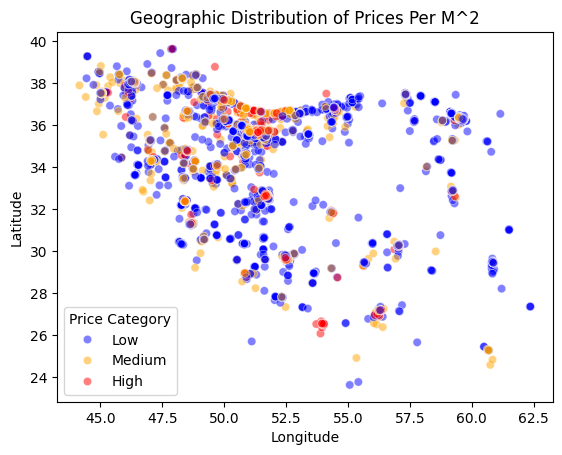

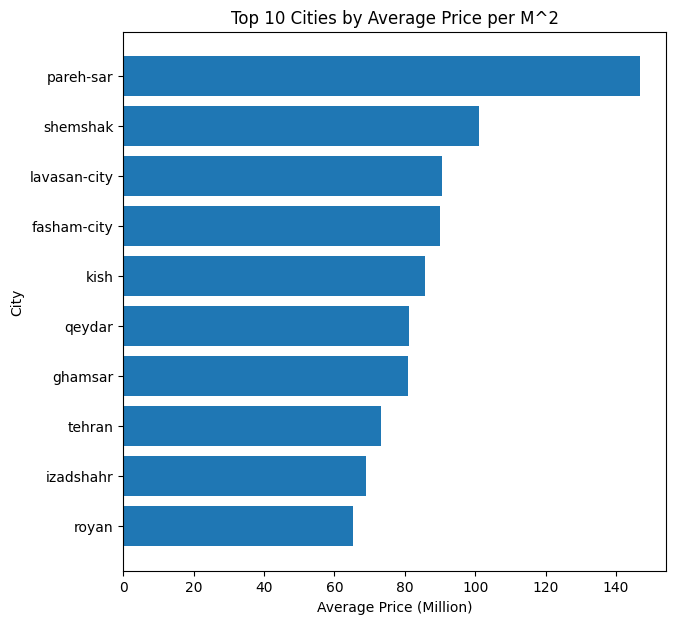

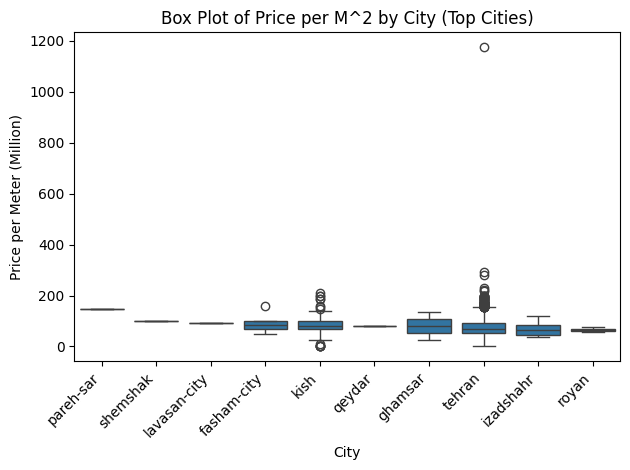

In [37]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['price_value'].quantile(0.25)
Q3 = data2['price_value'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data3 = data2[(data2['cat2_slug']=='residential-sell') &
              (data2['cat3_slug']=='apartment-sell') &
              (data2['price_value'] > lower_bound) &
              (data2['price_value'] < upper_bound)]

bins = [data3['price_per_meter'].min()-1, data3['price_per_meter'].quantile(0.33),
       data3['price_per_meter'].quantile(0.66), data3['price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data3['price_category'] = pd.cut(data3['price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data3,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()



avg_price_per_city = data3.groupby('city_slug')['price_per_meter'].mean().reset_index()
avg_price_per_city = avg_price_per_city.sort_values('price_per_meter', ascending=False)

avg_price_per_city = avg_price_per_city[avg_price_per_city['price_per_meter'].notnull()]

# Select top 10 cities for the bar chart
avg_price_per_city_top10 = avg_price_per_city.head(10)


plt.figure(figsize = (7, 7))
plt.barh(
    avg_price_per_city_top10['city_slug'],
    avg_price_per_city_top10['price_per_meter']
)
plt.xlabel('Average Price (Million)')
plt.ylabel('City')
plt.title('Top 10 Cities by Average Price per M^2')
plt.gca().invert_yaxis()
plt.show()

top_cities = avg_price_per_city.head(10)['city_slug'].tolist()
data3_top_cities = data3[data3['city_slug'].isin(top_cities)].copy()

#plt.figure(figsize=(7, 7))
sns.boxplot(x='city_slug', y='price_per_meter', data=data3_top_cities, order=top_cities) # Order by average price
plt.title('Box Plot of Price per M^2 by City (Top Cities)')
plt.xlabel('City')
plt.ylabel('Price per Meter (Million)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

دیتا فریم مربوط به آگهی هایی که رنج قیمت برای هر مترمربع چه اجاره و چه فروش معقول است.

In [38]:

data2_copy = data2.copy()
# Calculate Q1, Q3, and IQR for 'price_value'
Q1_p = data2['price_per_meter'].quantile(0.25)
Q3_p = data2['price_per_meter'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Define the lower and upper bounds for outliers
lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

Q1_r = data2['rent_price_per_meter'].quantile(0.25)
Q3_r = data2['rent_price_per_meter'].quantile(0.75)
IQR_r = Q3_r - Q1_r

# Define the lower and upper bounds for outliers
lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

data2_copy = data2_copy[(data2_copy['price_per_meter'] > lower_bound_p) & (data2_copy['price_per_meter'] < upper_bound_p) |
                   (data2_copy['rent_price_per_meter'] > lower_bound_r) & (data2_copy['rent_price_per_meter'] < upper_bound_r)
                   ]


#remove price outliers
data2_copy.shape

(126025, 63)

قیمت هر مترمربع آگهی ها برای فروش بر اساس سال ساخت

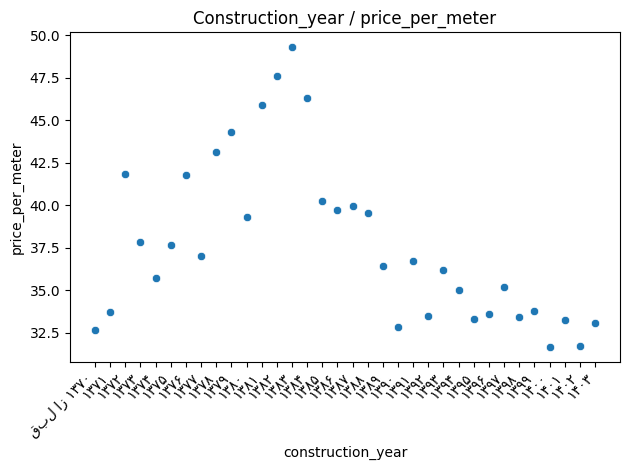

In [39]:
avg_price_per_year = data2_copy.groupby('construction_year')['price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
avg_price_per_year = avg_price_per_year[avg_price_per_year['price_per_meter'].notnull()]

#plt.figure(figsize = (15, 5))
sns.scatterplot(x = 'construction_year', y = 'price_per_meter', data = avg_price_per_year)
plt.title('Construction_year / price_per_meter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

قیمت اجاره هر مترمربع بر اساس سال ساخت


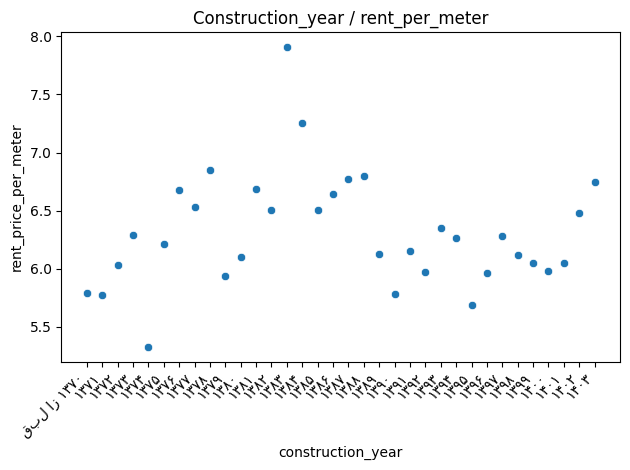

In [40]:
avg_rent_per_year = data2_copy.groupby('construction_year')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_year = avg_rent_per_year.sort_values('construction_year', ascending=True)
avg_rent_per_year = avg_rent_per_year[avg_rent_per_year['rent_price_per_meter'].notnull()]

#plt.figure(figsize = (10, 5))
sns.scatterplot(x = 'construction_year', y = 'rent_price_per_meter', data = avg_rent_per_year)
plt.title('Construction_year / rent_per_meter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

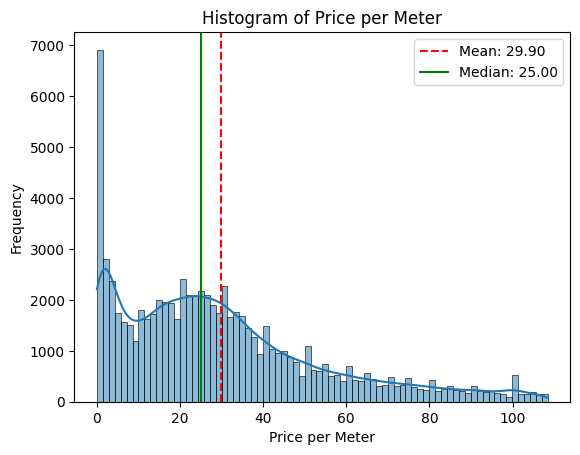

In [41]:
from scipy.stats import skew
data2_copy = data2.copy()
# Calculate Q1, Q3, and IQR for 'price_value'
Q1_p = data2['price_per_meter'].quantile(0.25)
Q3_p = data2['price_per_meter'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Define the lower and upper bounds for outliers
lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

data2_copy = data2_copy[(data2_copy['price_per_meter'] > lower_bound_p) & (data2_copy['price_per_meter'] < upper_bound_p)]
#pd.save

#data2_copy.shape
#print(skew(data2[data2['price_per_meter'].notnull()]['price_per_meter']))
#print(skew(data2[data2['rent_price_per_meter'].notnull()]['rent_price_per_meter']))
#print(skew(data2['rent_price_per_meter']))

price_per_meter = data2_copy[data2_copy['price_per_meter'].notnull()]['price_per_meter'].round(2)

mean = np.mean(price_per_meter)
median = np.median(price_per_meter)

sns.histplot(price_per_meter, kde=True)


plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')


plt.axvline(median, color='green', linestyle='-', label=f'Median: {median:.2f}')

plt.title('Histogram of Price per Meter')
plt.xlabel('Price per Meter')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [42]:
#داده های قبل و بعد از چارک اول و سوم که به عنوان پرت در نظر گرفته شده است  جدا شده اند
data_less_Q1 = data2[data2['price_per_meter']<Q1_p]
data_big_Q3 = data2[data2['price_per_meter']>Q3_p]
data_less_Q1.to_csv('less_Q1.csv', index=False)
data_big_Q3.to_csv('big_Q3.csv', index=False)

**ارزانترین شهرها برای اجاره مسکن**



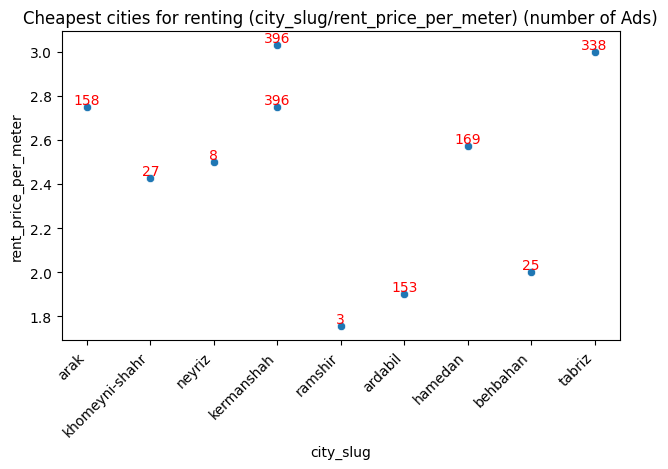

In [43]:
#cheap city for renting

Q1_r = data2['rent_price_per_meter'].quantile(0.25)
Q3_r = data2['rent_price_per_meter'].quantile(0.75)
IQR_r = Q3_r - Q1_r

# Define the lower and upper bounds for outliers
lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

#consider non-outliers data
df_rent = data2[(data2['rent_price_per_meter'] >= lower_bound_r) & (data2['rent_price_per_meter'] <= upper_bound_r)]

df_rent = df_rent[data2['cat2_slug'].str.find('rent') != -1]

city_cheap_rent = df_rent[df_rent['rent_price_per_meter'] < Q1_r][['city_slug','rent_price_per_meter']]

city_cheap_rent.groupby('city_slug')['rent_price_per_meter'].mean().sort_values(ascending=False)

city_counts = city_cheap_rent['city_slug'].value_counts().reset_index(name='count')

city_cheap_rent = city_cheap_rent.merge(city_counts, on='city_slug')

#print(city_cheap_rent.head(10))
#plt.figure(figsize = (10, 5))

sns.scatterplot(x = 'city_slug', y = 'rent_price_per_meter', data = city_cheap_rent.head(10))
plt.title('Cheapest cities for renting (city_slug/rent_price_per_meter) (number of Ads)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
for i,row in city_cheap_rent.head(10).iterrows():
    plt.text(row['city_slug'], row['rent_price_per_meter'], str(row['count']), ha='center', va='bottom',color = 'red')

plt.show()

<div dir="rtl">
  <h2> شناسایی محله‌های سودآور سرمایه‌گذاری، باید دو شاخص کلیدی را به‌صورت همزمان تحلیل کنیم:</h2>
  <p> هدف:</p>
  <p>پیدا کردن محله‌هایی که:</p>
  <ul>
    <li>رشد قیمت پایدار یا مثبت در طول زمان دارند (قیمت رو به افزایش و نه نوسانی یا نزولی)،</li>
    <li>عرضهٔ کم (تعداد آگهی کم نسبت به سایر محله‌ها) &rArr; یعنی تقاضا بالاتر از عرضه است، پس ملک دیرتر خالی می‌ماند و ارزش سرمایه‌ای بیشتر می‌شود.</li>
  </ul>
</div>


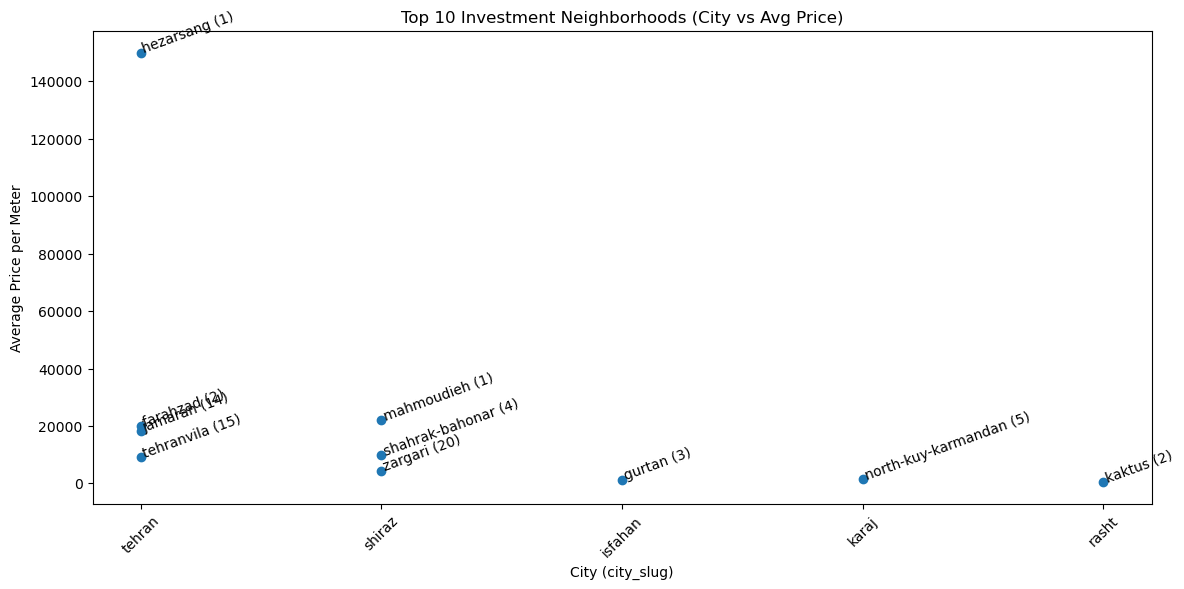

In [ ]:
columns_need= ['city_slug', 'neighborhood_slug', 'price_per_meter']
df = data2[columns_need].copy()

df = df.dropna(subset=['city_slug', 'neighborhood_slug', 'price_per_meter'])

# Group by city and neighborhood to get average price and number of ads
grouped = df.groupby(['city_slug', 'neighborhood_slug']).agg(
    avg_price_per_meter = ('price_per_meter', 'mean'),
    median_price_per_meter = ('price_per_meter', 'median'),
    ad_count = ('price_per_meter', 'count')
).reset_index()

#Sort results by average price
grouped_sorted = grouped.sort_values(by='avg_price_per_meter', ascending=False)


grouped['investment_score'] = (
    (grouped['avg_price_per_meter'] / grouped['avg_price_per_meter'].max()) *
    (1 / (grouped['ad_count']))
)


top_10 = grouped.sort_values(by='investment_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.scatter(top_10['city_slug'], top_10['avg_price_per_meter'])

for i in range(len(top_10)):
    plt.text(
        (top_10['city_slug'].iloc[i]),
        top_10['avg_price_per_meter'].iloc[i],
        f"{top_10['neighborhood_slug'].iloc[i]} ({top_10['ad_count'].iloc[i]})",
        fontsize=10,
        rotation=20    )

plt.xlabel("City (city_slug)")
plt.ylabel("Average Price per Meter")
plt.title("Top 10 Investment Neighborhoods (City vs Avg Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df = data2[['construction_year','price_per_meter']].copy()

In [ ]:
print(df['construction_year'].dtype)
print(df['construction_year'].unique())


object
['۱۳۹۰' '۱۴۰۳' '۱۴۰۲' '۱۳۹۹' nan '۱۳۹۷' '۱۳۹۵' '۱۳۸۵' '۱۳۷۲' '۱۳۸۶' '۱۳۸۹'
 '۱۴۰۱' '۱۳۹۳' '۱۳۹۴' '۱۳۸۸' '۱۳۹۸' '۱۳۹۶' '۱۳۷۶' '۱۳۷۱' '۱۳۸۷' '۱۳۷۴'
 '۱۳۹۲' '۱۴۰۰' 'قبل از ۱۳۷۰' '۱۳۸۱' '۱۳۹۱' '۱۳۸۰' '۱۳۷۹' '۱۳۸۲' '۱۳۸۳'
 '۱۳۷۳' '۱۳۷۸' '۱۳۷۵' '۱۳۸۴' '۱۳۷۷']


In [ ]:
persian_to_english_digits = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

def convert_persian_year_to_english(year_str):
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str).strip()
    if 'قبل از' in year_str:
        return 1369
    try:
        # Convert Persian digits to English digits
        english_year_str = year_str.translate(persian_to_english_digits)
        return int(english_year_str)
    except ValueError:
        return np.nan

# Apply the conversion function
df['construction_year'] = df['construction_year'].apply(convert_persian_year_to_english)

# Convert the column to numeric, coercing errors to NaN
df['construction_year'] = pd.to_numeric(df['construction_year'], errors='coerce')

# Remove rows where construction_year is NaN
original_rows = df.shape[0]
df.dropna(subset=['construction_year'], inplace=True)
removed_rows = original_rows - df.shape[0]

max_year = df['construction_year'].max()
recent_years = [year for year in range(int(max_year) - 4, int(max_year) + 1)]

print(f"Considering recent construction years from {min(recent_years)} to {max_year}.")

Q3_price_per_meter = df['price_per_meter'].quantile(0.75)

print(f"The 75th percentile (Q3) for 'price_per_meter' is: {Q3_price_per_meter}")

recent_construction_data = df[df['construction_year'].isin(recent_years)]

high_priced_new_houses = recent_construction_data[recent_construction_data['price_per_meter'] > Q3_price_per_meter]

percentage_high_priced_new_houses = (len(high_priced_new_houses) / len(recent_construction_data)) * 100 if len(recent_construction_data) > 0 else 0

print(f"Number of houses built in recent years ({min(recent_years)}-{max(recent_years)}): {len(recent_construction_data)}")
print(f"Number of high-priced houses among these: {len(high_priced_new_houses)}")
print(f"Percentage of high-priced new houses: {percentage_high_priced_new_houses:.2f}%")

Considering recent construction years from 1399 to 1403.0.
The 75th percentile (Q3) for 'price_per_meter' is: 58.06451612903226
Number of houses built in recent years (1399-1403): 43884
Number of high-priced houses among these: 6014
Percentage of high-priced new houses: 13.70%


**Reasoning**:
To visualize the percentage of high-priced new houses, we created a pie chart using the calculated percentage and its complement




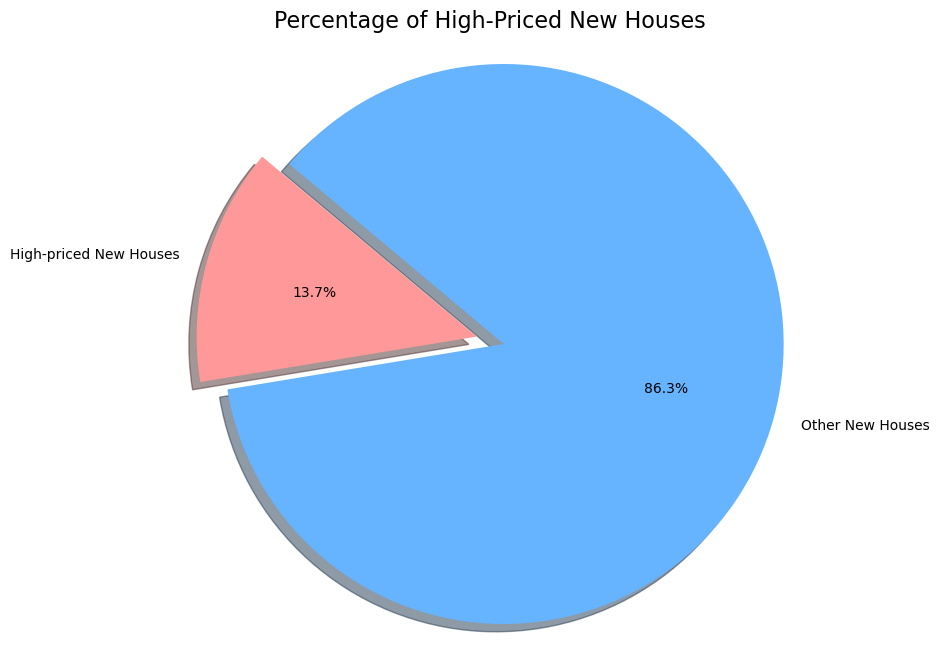

In [ ]:
labels = ['High-priced New Houses', 'Other New Houses']
sizes = [percentage_high_priced_new_houses, 100 - percentage_high_priced_new_houses]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # Explode the 1st slice (High-priced New Houses)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of High-Priced New Houses', fontsize=16)
plt.show()

substitute building size with 1 m^2 with the meter extracted from description

In [ ]:

df = data2[['description','building_size']]
df['description'] = df['description'].astype(str)

def extract_meter_numbers(description):
    if pd.isna(description):
        return np.nan
    matches = re.findall(r'(\d+)\s*متر\s*', description)
    if matches:
        return float(matches[0])
    return np.nan

df['meter_numbers'] = df['description'].apply(extract_meter_numbers)
df.to_csv('meter.csv', index=False,encoding = 'utf-8')
counter = 0
for row in df.itertuples():
  if row.building_size == 1:
    df['building_size'][counter] = row.meter_numbers
  counter += 1

df.head()

,description,building_size,meter_numbers
0,✔مناسب مشاغل پروتئنی و دفتر بیمه و لبنیات \n...,25.0,NaN
1,با سلام خدمت هشهریان عزیز\n\nواحد دومین قطعه ا...,102.0,102.0
2,۱۳۵ متر واحد لوکس به همراه تراس قابل چیدمان \n...,168.0,135.0
3,⚜️⚜️⚜️املاک بزرگ باور⚜️⚜️⚜️\n\n56 متر غرق در ن...,56.0,56.0
4,سلام درود همشهریان و مهمان های عزیز با ما با ب...,200000.0,NaN


In [ ]:
data.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

ذینفع : طراحان داخلی

با استفاده از این روش تحلیلی، می‌توانیم شهرها و مناطقی را شناسایی کنیم که بالاترین پتانسیل برای ارائه خدمات طراحی داخلی را دارند. این تحلیل بر اساس داده‌های واقعی املاک انجام می‌شود و به شما کمک می‌کند تا تصمیم‌گیری دقیق‌تر و هدفمندتری داشته باشید.

به کمک این روش می‌توانید:

✅ تشخیص دهید کدام شهرها بیشترین ظرفیت و تقاضا برای پروژه‌های طراحی داخلی را دارند.

✅ بفهمید در کدام مناطق تعداد بازسازی و نوسازی بیشتر است؛ یعنی مشتریانی که آماده همکاری با طراح داخلی هستند.

✅ شناسایی کنید کدام مناطق دارای بیشترین فایل پیش‌فروش هستند؛ یعنی ساختمان‌های تازه‌ساز با پتانسیل طراحی داخلی از صفر.

✅ بررسی کنید در کدام مناطق میانگین متراژ واحدها بالاتر است؛ یعنی پروژه‌هایی بزرگ‌تر، لوکس‌تر و سودآورتر برای طراح داخلی.

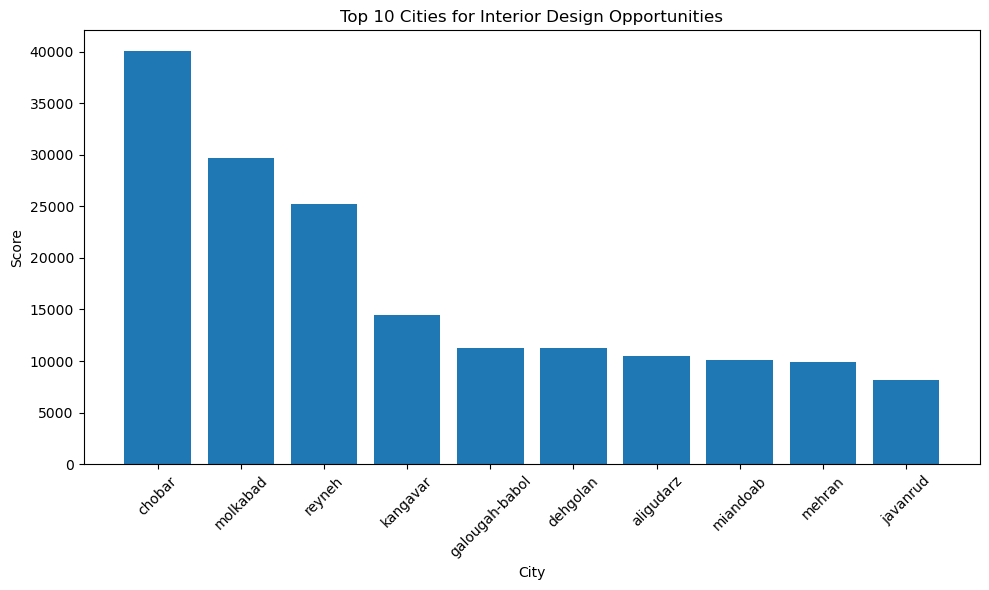

In [ ]:
df = data2[['cat3_slug','city_slug', 'neighborhood_slug', 'price_per_meter','building_size','is_rebuilt']].copy()
rebuilt_houses = df[df['is_rebuilt'] == True]
pre_sell = df[df['cat3_slug'] == 'presell']

rebuilt_by_city = rebuilt_houses.groupby('city_slug').size().reset_index(name='rebuilt_count')
pre_sell_by_city = pre_sell.groupby('city_slug').size().reset_index(name='pre_sell_count')
large_houses = df.groupby('city_slug')['building_size'].mean().reset_index(name='avg_building_size')

#merge all these
city_summary = rebuilt_by_city.merge(pre_sell_by_city, on='city_slug', how='outer') \
                              .merge(large_houses, on='city_slug', how='outer')

#calculat a score based on the importannce of each feature! rebuilt is most important.
city_summary = city_summary.fillna(0)
city_summary['score'] = (
    city_summary['rebuilt_count'] * 0.6 +
    city_summary['pre_sell_count'] * 0.3 +
    city_summary['avg_building_size'] * 0.1
)

best_cities = city_summary.sort_values('score', ascending=False).head(10)

#plot
plt.figure(figsize=(10, 6))
plt.bar(best_cities['city_slug'], best_cities['score'])
plt.title('Top 10 Cities for Interior Design Opportunities')
plt.xlabel('City')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<p>با استفاده از این تحلیل:</p>
<ul>
  <li>✔ مشخص می‌کنید <strong>کدام شهرها و محله‌ها بیشترین سود را برای راه‌اندازی دفتر دارند</strong>.</li>
  <li>✔ مناطقی که ترکیبی از قیمت بالا، واحدهای بزرگ و معاملات متعدد دارند، به عنوان <strong>مناطق بهینه برای تمرکز فعالیت</strong> شناسایی می‌شوند.</li>
  <li>✔ تصمیم‌گیری شما برای جذب مشتری و انتخاب محل دفتر با داده‌های واقعی و عددی پشتیبانی می‌شود.</li>
</ul>

<p>بنابراین، تحلیل Profit Score به شما امکان می‌دهد <strong>استراتژی هوشمندانه‌ای برای افزایش سود و بهره‌وری کسب‌وکار مشاور املاک</strong> طراحی کنید.</p>
</div>


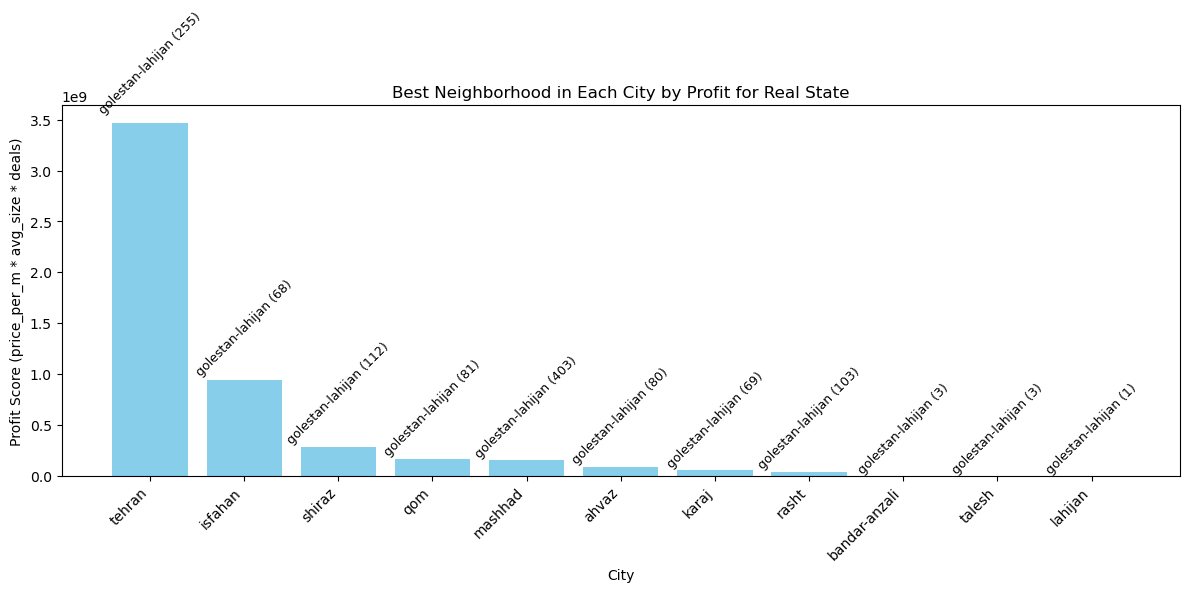

In [ ]:
df = data2[['city_slug', 'neighborhood_slug', 'price_per_meter','building_size','price_value']].copy()

# Group by city_slug and neighborhood_slug
grouped = df.groupby(['city_slug','neighborhood_slug']).agg(
    avg_price_value=('price_value', 'mean'),
    avg_price_per_m=('price_per_meter', 'mean'),
    avg_size=('building_size', 'mean'),
    deal_count=('price_value', 'count')
).reset_index()

# formula is profit_score = price_per_m * size_of_house * number of contract
grouped['profit_score'] = grouped['avg_price_per_m'] * grouped['avg_size'] * grouped['deal_count']

best_neighborhoods = grouped.loc[grouped.groupby('city_slug')['profit_score'].idxmax()]
best_neighborhoods = best_neighborhoods.sort_values('profit_score', ascending=False)

#print(best_neighborhoods)

plt.figure(figsize=(12,6))
bars = plt.bar(best_neighborhoods['city_slug'], best_neighborhoods['profit_score'], color='skyblue')

# Step 3: Add neighborhood name and number of deals on top of each bar
for bar, heigh, deals in zip(bars, best_neighborhoods['neighborhood_slug'], best_neighborhoods['deal_count']):
    height = bar.get_height()
    # Write neighborhood name
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + height*0.02,
        f"{neigh} ({deals})",
        ha='center', va='bottom', fontsize=9, rotation=45,
        color='black'
    )

plt.xticks(rotation=45, ha='right')
plt.title('Best Neighborhood in Each City by Profit for Real State')
plt.xlabel('City')
plt.ylabel('Profit Score (price_per_m * avg_size * deals)')
plt.tight_layout()
plt.show()


In [ ]:
data.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [ ]:
data2.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [ ]:
data2['price_value']

0                  NaN
1         3.350000e+09
2                  NaN
3         1.250000e+09
4                  NaN
              ...     
149995    1.500000e+09
149996             NaN
149997             NaN
149998             NaN
149999    9.340000e+08
Name: price_value, Length: 150000, dtype: float64

In [ ]:
data2['rent_value']

0         28000000.0
1                NaN
2         60000000.0
3                NaN
4                NaN
             ...    
149995           NaN
149996     6000000.0
149997     5500000.0
149998           NaN
149999           NaN
Name: rent_value, Length: 150000, dtype: float64

In [ ]:
df = data2[['city_slug', 'neighborhood_slug', 'rent_value','credit_value','construction_year', 'rent_price_per_meter', 'cat2_slug','cat3_slug']]
df


,city_slug,neighborhood_slug,rent_value,credit_value,construction_year,rent_price_per_meter,cat2_slug,cat3_slug
0,tehran,kooy-e-bimeh,28000000.0,3.000000e+08,۱۳۹۰,45.600000,commercial-rent,shop-rent
1,urmia,NaN,NaN,NaN,۱۴۰۳,NaN,residential-sell,apartment-sell
2,tehran,niavaran,60000000.0,3.000000e+09,۱۴۰۲,28.571429,commercial-rent,office-rent
3,andisheh-new-town,NaN,NaN,NaN,۱۳۹۹,NaN,residential-sell,apartment-sell
4,behbahan,NaN,NaN,NaN,NaN,NaN,temporary-rent,villa
...,...,...,...,...,...,...,...,...
149995,damavand,NaN,NaN,NaN,۱۴۰۱,NaN,residential-sell,house-villa-sell
149996,kerman,NaN,6000000.0,1.500000e+08,۱۳۹۳,3.666667,residential-rent,apartment-rent
149997,zanjan,NaN,5500000.0,1.500000e+08,۱۳۷۵,2.250000,residential-rent,house-villa-rent
149998,shahriar-city,NaN,NaN,NaN,NaN,NaN,temporary-rent,villa


In [ ]:
df['cat2_slug'].value_counts(
)

cat2_slug
residential-sell        83958
residential-rent        41337
commercial-rent         11507
commercial-sell          5854
temporary-rent           4404
real-estate-services     2940
Name: count, dtype: int64

In [ ]:
df['cat3_slug'].value_counts()

cat3_slug
apartment-sell                        45804
apartment-rent                        31635
plot-old                              19860
house-villa-sell                      18294
house-villa-rent                       9702
shop-rent                              6915
shop-sell                              3307
office-rent                            3250
suite-apartment                        2421
presell                                2366
villa                                  1896
industry-agriculture-business-sell     1775
industry-agriculture-business-rent     1342
office-sell                             772
partnership                             574
workspace                                87
Name: count, dtype: int64

In [ ]:
df.groupby('cat2_slug')['cat3_slug'].value_counts()

cat2_slug             cat3_slug                         
commercial-rent       shop-rent                              6915
                      office-rent                            3250
                      industry-agriculture-business-rent     1342
commercial-sell       shop-sell                              3307
                      industry-agriculture-business-sell     1775
                      office-sell                             772
real-estate-services  presell                                2366
                      partnership                             574
residential-rent      apartment-rent                        31635
                      house-villa-rent                       9702
residential-sell      apartment-sell                        45804
                      plot-old                              19860
                      house-villa-sell                      18294
temporary-rent        suite-apartment                        2421
                   

In [ ]:
df = df[df['cat2_slug']=='residential-rent']

In [ ]:
df['cat3_slug'].value_counts()

cat3_slug
apartment-rent      31635
house-villa-rent     9702
Name: count, dtype: int64

In [ ]:
# Avg for each neighbor

df_neighbor_avg_rent = df.groupby(['city_slug','neighborhood_slug']).agg(
    avg_rent_value = ('rent_value', 'mean'),
    avg_rent_per_meter = ('rent_price_per_meter', 'mean')
).reset_index()

df_neighbor_avg_rent

,city_slug,neighborhood_slug,avg_rent_value,avg_rent_per_meter
0,ahvaz,amaniyeh-ahvaz,2.500000e+05,5.239927
1,ahvaz,ariyashahr,4.066667e+06,4.646342
2,ahvaz,baharestan-ahvaz,1.118301e+06,3.124439
3,ahvaz,bahonar,1.313333e+06,5.567586
4,ahvaz,camplojonoobi,1.500000e+06,3.016315
...,...,...,...,...
1024,tehran,zahir-abad,5.076245e+06,7.640003
1025,tehran,zamzam,3.860000e+06,6.555691
1026,tehran,zargandeh,2.059091e+07,15.353768
1027,tehran,zarkesh,5.166667e+06,9.107668


محله هایی را پیدا کنیم که میانگین اجاره در آنها از میانگین متوسط شهرشان کمتر باشه

In [ ]:
#Avg for each City

df_avg_each_city = df.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()

df_avg_each_city.rename(columns={'rent_price_per_meter': 'avg_rent_city'}, inplace=True)

df_avg_each_city


,city_slug,avg_rent_city
0,Iranshahr,53.447897
1,Kordkuy,2.599186
2,aalasht,0.775000
3,abadan,3.191175
4,abadeh,62.713690
...,...,...
349,zarand,1.826370
350,zarghan,2.067315
351,zibakenar,4.410256
352,ziraab,2.817142


In [ ]:
df_merge = df_neighbor_avg_rent.merge(df_avg_each_city, on = 'city_slug')

df_merge



,city_slug,neighborhood_slug,avg_rent_value,avg_rent_per_meter,avg_rent_city
0,ahvaz,amaniyeh-ahvaz,2.500000e+05,5.239927,34648.892159
1,ahvaz,ariyashahr,4.066667e+06,4.646342,34648.892159
2,ahvaz,baharestan-ahvaz,1.118301e+06,3.124439,34648.892159
3,ahvaz,bahonar,1.313333e+06,5.567586,34648.892159
4,ahvaz,camplojonoobi,1.500000e+06,3.016315,34648.892159
...,...,...,...,...,...
1024,tehran,zahir-abad,5.076245e+06,7.640003,316.984588
1025,tehran,zamzam,3.860000e+06,6.555691,316.984588
1026,tehran,zargandeh,2.059091e+07,15.353768,316.984588
1027,tehran,zarkesh,5.166667e+06,9.107668,316.984588


In [ ]:
neighbor_under_avg = df_merge[df_merge['avg_rent_per_meter'] < df_merge['avg_rent_city']]

neighbor_under_avg['city_slug'].value_counts()

city_slug
tehran     329
isfahan    169
shiraz     147
mashhad    145
karaj       78
rasht       55
ahvaz       48
qom         19
lahijan      1
Name: count, dtype: int64

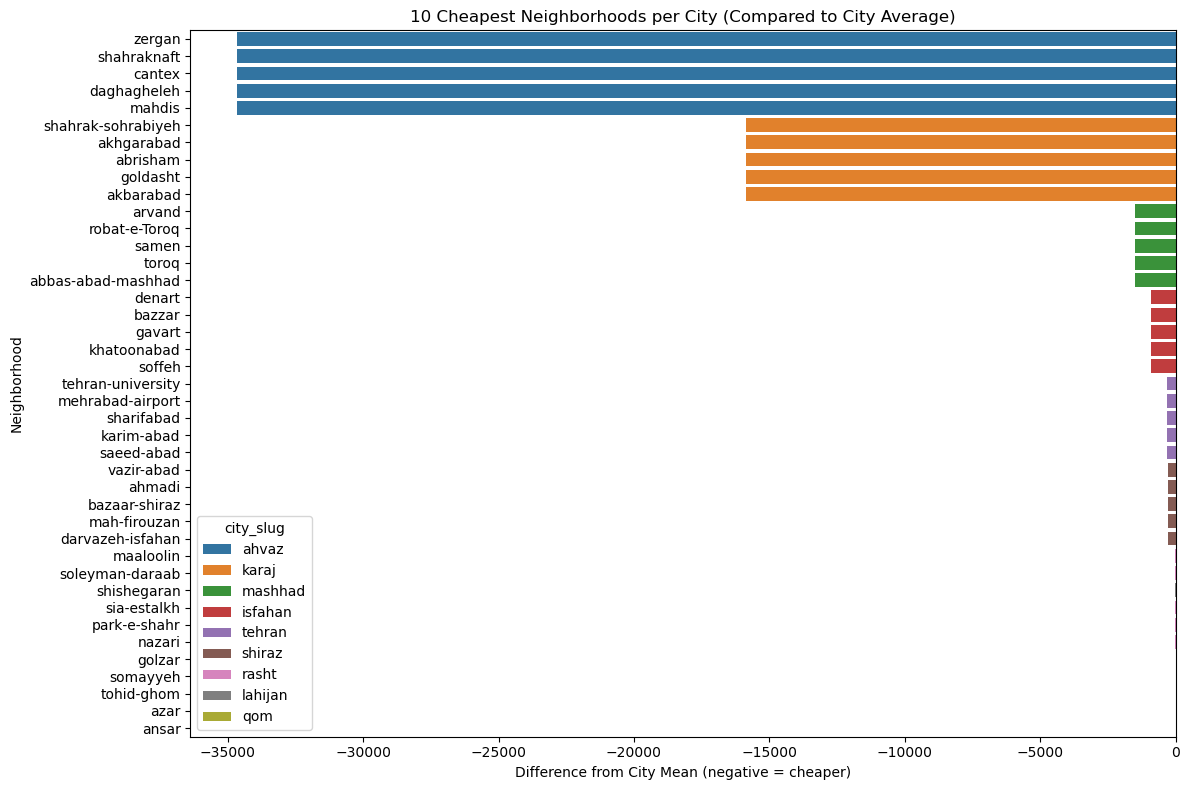

In [ ]:
neighbor_under_avg['diff_from_avg_city'] = neighbor_under_avg['avg_rent_per_meter'] - neighbor_under_avg['avg_rent_city']

top10_per_city = (
    neighbor_under_avg
    .sort_values(['city_slug', 'diff_from_avg_city'])
    .groupby('city_slug')
    .head(5)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top10_per_city.sort_values('diff_from_avg_city'),
    y='neighborhood_slug',
    x='diff_from_avg_city',
    hue='city_slug',
    dodge=False
)

plt.title('10 Cheapest Neighborhoods per City (Compared to City Average)')
plt.xlabel('Difference from City Mean (negative = cheaper)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()




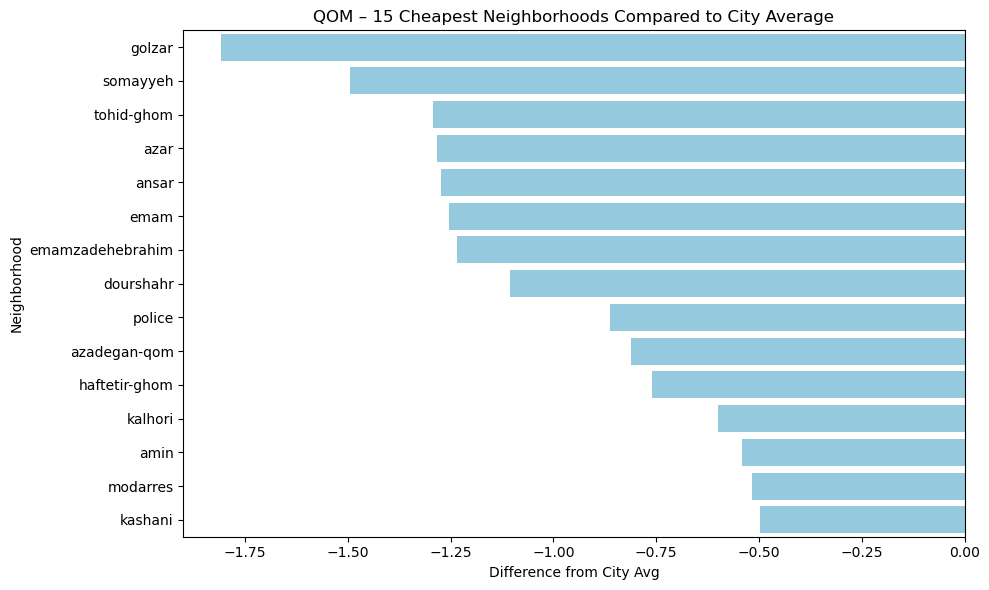

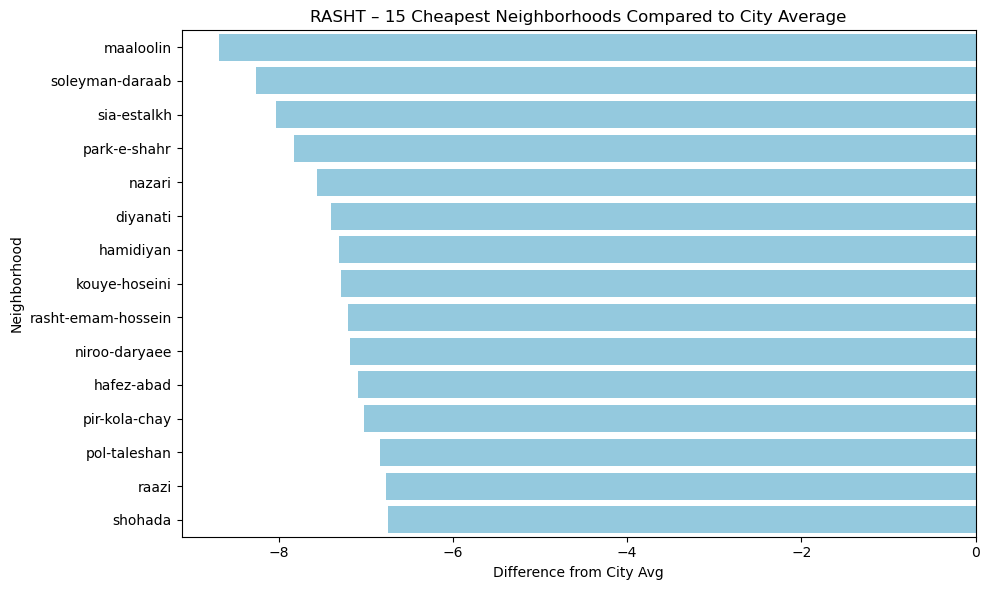

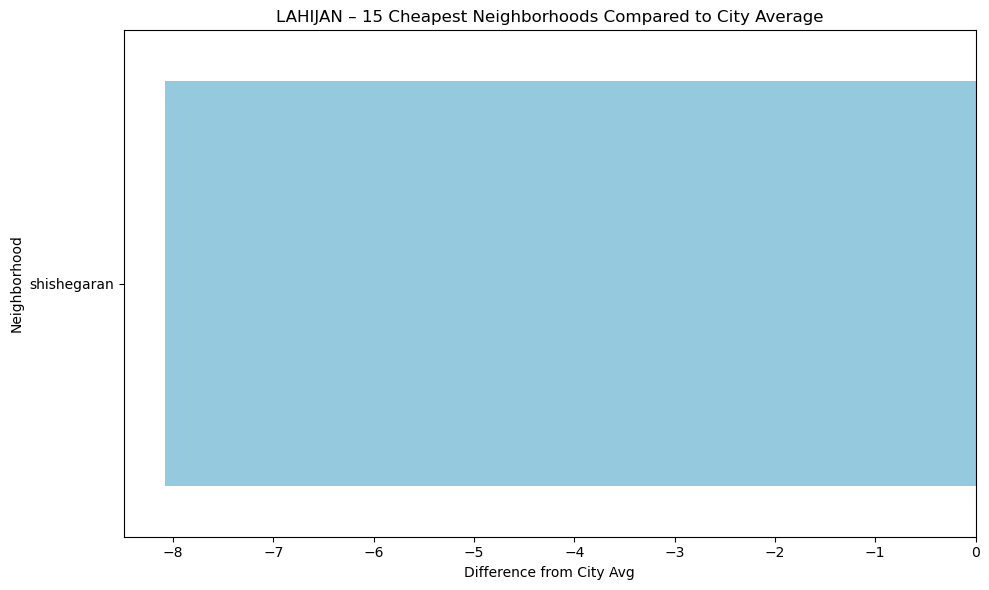

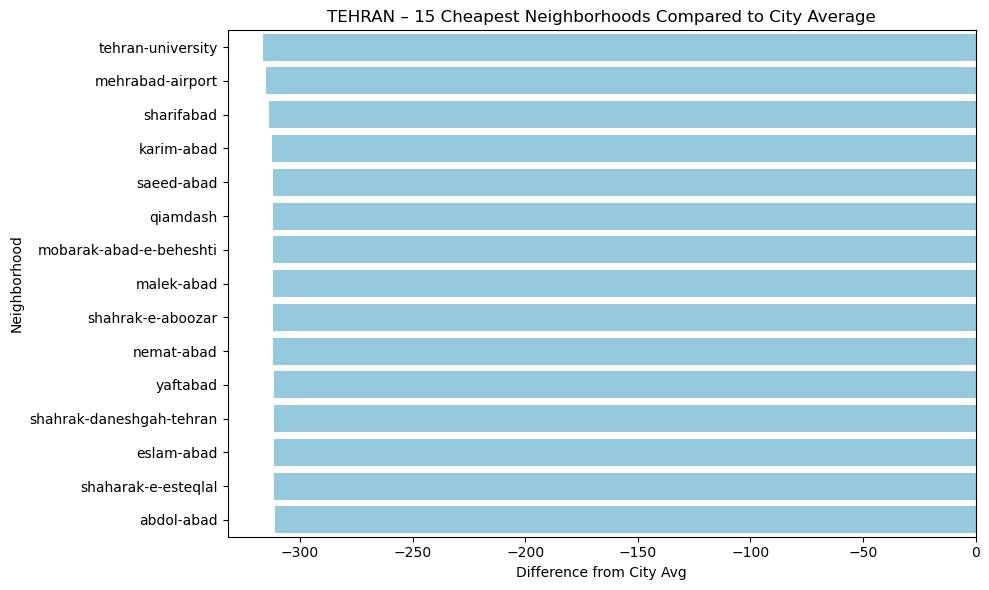

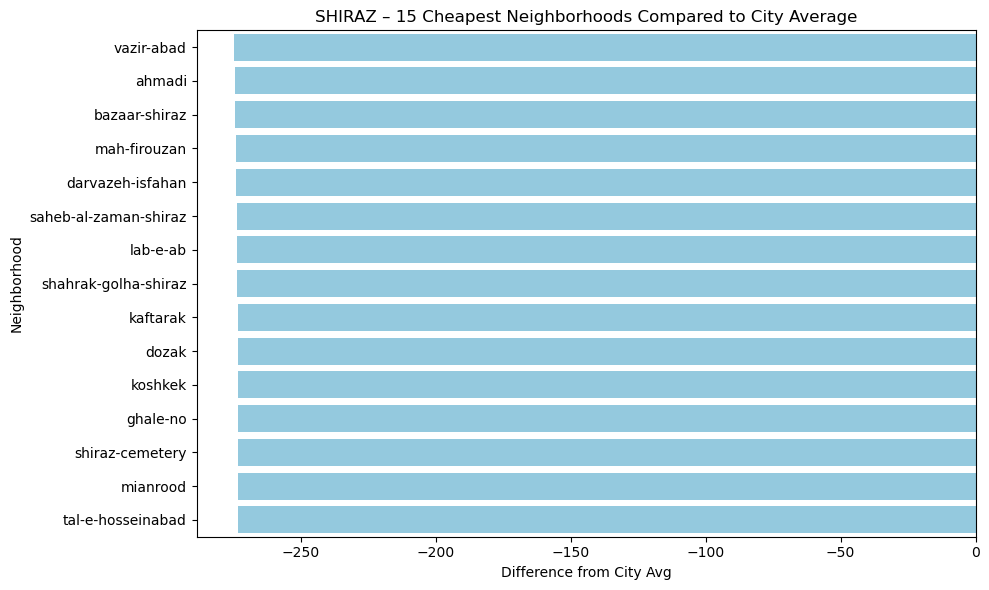

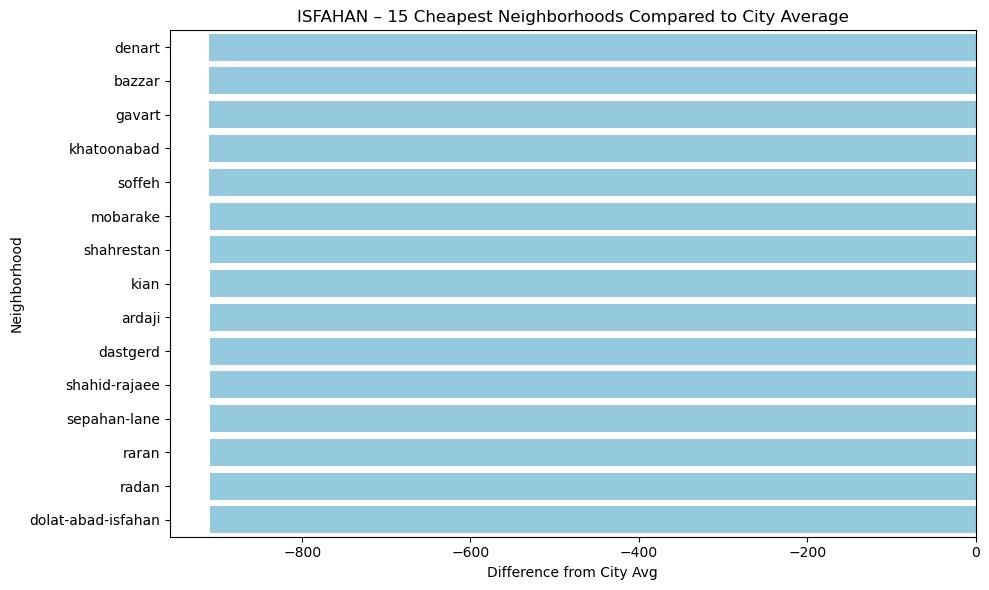

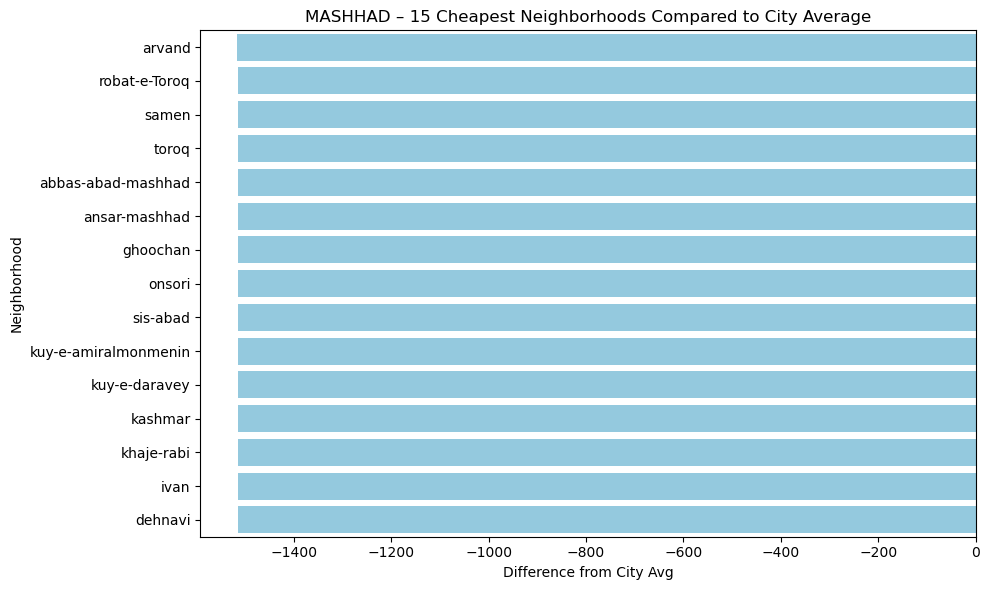

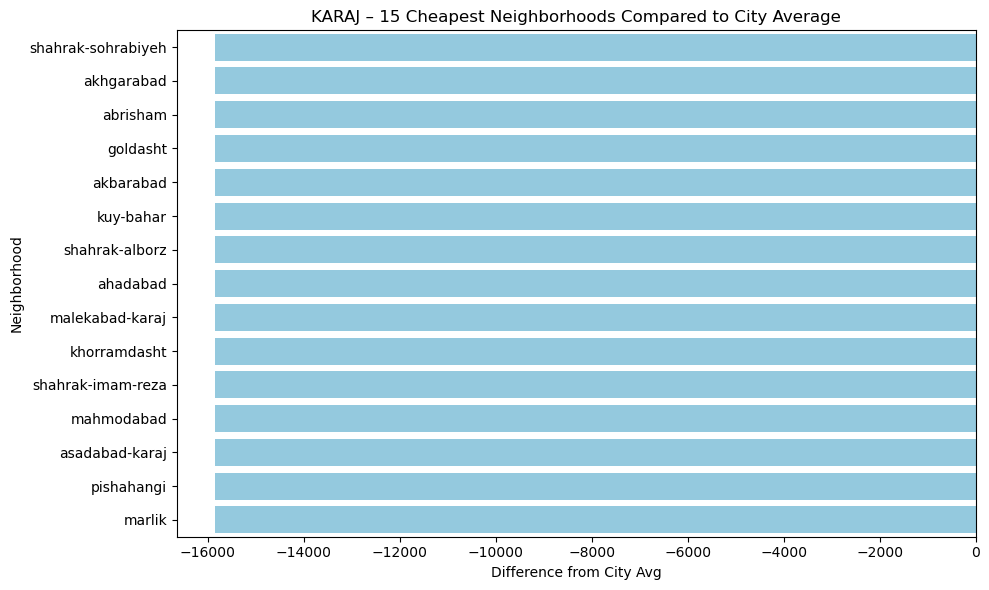

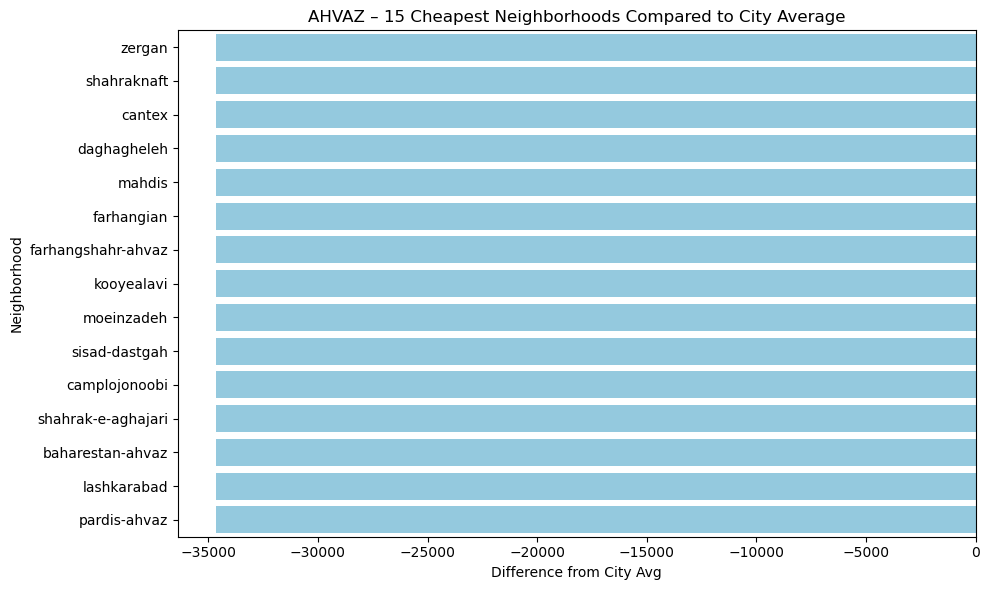

In [ ]:


cities = neighbor_under_avg['city_slug'].unique()

for city in cities:
    city_data = neighbor_under_avg[neighbor_under_avg['city_slug'] == city]

    top15 = city_data.nsmallest(15, 'diff_from_avg_city')

    plt.figure(figsize=(10,6))
    sns.barplot(
        data=top15.sort_values('diff_from_avg_city'),
        y='neighborhood_slug',
        x='diff_from_avg_city',
        color='skyblue'
    )

    plt.title(f'{city.upper()} – 15 Cheapest Neighborhoods Compared to City Average')
    plt.xlabel('Difference from City Avg')
    plt.ylabel('Neighborhood')
    plt.tight_layout()
    plt.show()



In [64]:
#extract meter from descritpion
def extract_meter_numbers(description):
    if pd.isna(description):
        return np.nan
    matches = re.findall(r'(\d+)\s*متر\s*', description)
    if matches:
        return float(matches[0])
    return np.nan

persian_to_english_digits = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

def convert_persian_year_to_english(year_str):
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str).strip()
    if 'قبل از' in year_str:
        # Assuming 'قبل از ۱۳۷۰' means 1369 as used in a prior cell
        return 1369
    try:
        english_year_str = year_str.translate(persian_to_english_digits)
        return int(english_year_str)
    except ValueError:
        return np.nan

#cleaning data frame function
def cleaning_data(data: pd.DataFrame) -> pd.DataFrame:

###->    # 1. Remove columns that more than 90% of its data is NA
    data = data.dropna(axis=1, thresh=int(0.1 * len(data)))

###->     #2. complete building size with 1 m^2 with number exctracter from description
    data['description'].astype(str)
    data['meter_numbers'] = data['description'].apply(extract_meter_numbers)
    counter = 0
    for row in data.itertuples():
      if row.building_size == 1:
        data['building_size'][counter] = row.meter_numbers
      counter += 1
    data = data.drop(columns=['meter_numbers'])

###->     #3. remove outliers from price and rent value by using price/M^2 and rent/M^2

    #calculate price per square meter and rent per square meter
    data['price_per_meter'] = (data['price_value'] / data['building_size'])/1000000

    #since we have credit and rent price we need total rent
    data['total_rent'] = data['rent_value']*30 + data['credit_value']
    data['rent_price_per_meter'] = (data['total_rent'] / data['building_size'])/1000000

    # Calculate Q1, Q3, and IQR for 'price_value'
    Q1_p = data['price_per_meter'].quantile(0.25)
    Q3_p = data['price_per_meter'].quantile(0.75)
    IQR_p = Q3_p - Q1_p

    # Define the lower and upper bounds for outliers in price values
    lower_bound_p = Q1_p - 1.5 * IQR_p
    upper_bound_p = Q3_p + 1.5 * IQR_p

    # Calculate Q1, Q3, and IQR for 'rent_value'
    Q1_r = data['rent_price_per_meter'].quantile(0.25)
    Q3_r = data['rent_price_per_meter'].quantile(0.75)
    IQR_r = Q3_r - Q1_r

    # Define the lower and upper bounds for outliers in rent values
    lower_bound_r = Q1_r - 1.5 * IQR_r
    upper_bound_r = Q3_r + 1.5 * IQR_r

    data = data[(data['price_per_meter'] > lower_bound_p) & (data['price_per_meter'] < upper_bound_p) |
                   (data['rent_price_per_meter'] > lower_bound_r) & (data['rent_price_per_meter'] < upper_bound_r)
                   ]


###->     #4. Make some columns' data standard

    ### rooms_count
    data['rooms_count'] = data['rooms_count'].replace({
   'یک' : 1,
    'دو' : 2,
    'سه' : 3,
    'چهار': 4,
    'بدون اتاق' : 0,
    'پنج یا بیشتر' : 5    })

    data['rooms_count'].astype('Int32')



###->     #5. Add a Column called size_per_room

    data['size_per_room'] = data['building_size'] / (data['rooms_count'] + 1)

###->     #6. remove duplicated rows in data frame
    data = data.drop_duplicates(keep = 'last').reset_index(drop = True)


###->     #7.General Cleaning for boolian, numerical and object types of data


    numeric_features = [
            'rent_value', 'credit_value', 'rent_credit_transform',
            'transformable_price', 'transformable_credit', 'transformable_rent',
            'land_size', 'building_size', 'floor', 'rooms_count',
            'total_floors_count', 'unit_per_floor', 'construction_year',
            'location_latitude', 'location_longitude', 'location_radius',
            'rent_price_per_meter', 'price_per_meter','total_rent'
        ]
    boolean_features = [
            'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking',
            'is_rebuilt', 'has_warm_water_provider', 'has_heating_system',
            'has_cooling_system', 'has_restroom'
        ]

    categorical_features = [
            'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
            'user_type', 'rent_type', 'price_mode', 'rent_mode',
            'deed_type', 'building_direction', 'floor_material'
        ]

    ###->     #8.Handle construction year preprocessing
    data['construction_year'] = data['construction_year'].apply(convert_persian_year_to_english)
    data['construction_year'] = pd.to_numeric(data['construction_year'], errors='coerce')
    data['construction_year'].fillna(data['construction_year'].median(), inplace=True)


    # Fill NaN values in 'construction_year' with the median
    median_construction_year = data['construction_year'].median()
    data['construction_year'].fillna(median_construction_year, inplace=True)
    
    for col in numeric_features:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

    for col in boolean_features:
        if col in data.columns:
            data[col] = data[col].fillna(0)

    for col in categorical_features:
        if col in data.columns:
            data[col] = data[col].fillna('unknown').astype(str)


###->     #9.Combine Price Mode and Rent Mode - Combine Price value and Rent value
    data['mode_rent_or_price'] = data['rent_mode'].combine_first(data['price_mode'])
    data['value_rent_or_price'] = data['rent_price_per_meter'].combine_first(data['price_per_meter'])

###->     #10. Remove missing values in target column
    data = data.dropna(subset=['value_rent_or_price'])





    return data




df = cleaning_data(data)


<p style="font-family:Nazanin; font-size:200%; text-align:right;color:blue;" dir="rtl">
    بخش پنجم : خوشه بندی آگهی های املاک
    
</p>

<div dir="rtl">
<p style="direction: rtl; text-align: right;">
<h3>پیش پردازش :</h3>
 ا انتخاب ستون‌های مرتبط، مدیریت مقادیر گمشده، تبدیل ستون‌هایی با مقادیر بولی‌شبیه و سال‌های فارسی، کدگذاری ویژگی‌های دسته‌ای، و مقیاس‌بندی داده‌های عددی.
</p>

</div>

In [56]:
df_clustering = df.copy()

# Identify boolean-like columns and convert to 0/1, handling NaNs
boolean_cols = [col for col in df_clustering.columns if col.startswith('has_') or col == 'is_rebuilt']
for col in boolean_cols:
    if col in df_clustering.columns:
        # Ensure all values are string, map 'TRUE'/'FALSE' and fill NaNs
        df_clustering[col] = df_clustering[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, 'NAN': 0}).fillna(0).astype(int)

# Define numerical features, including the processed 'construction_year' and boolean columns
numerical_features = ['price_per_meter', 'rent_price_per_meter', 'building_size', 'rooms_count','construction_year'] + boolean_cols

# Define categorical features
categorical_features = ['city_slug', 'cat2_slug', 'cat3_slug', 'deed_type', 'user_type', 'building_direction', 'floor_material']

# Create a new DataFrame df_clustering_processed by selecting only the defined columns
all_selected_features = numerical_features + categorical_features
df_clustering_processed = df_clustering[all_selected_features].copy()

# Handle missing values in df_clustering_processed
# Impute numerical columns with median
for col in numerical_features:
    if col in df_clustering_processed.columns:
        median_val = df_clustering_processed[col].median()
        df_clustering_processed[col].fillna(median_val, inplace=True)

# Impute categorical columns with mode
for col in categorical_features:
    if col in df_clustering_processed.columns:
        mode_val = df_clustering_processed[col].mode()[0] # .mode() can return multiple if ties
        df_clustering_processed[col].fillna(mode_val, inplace=True)

# Perform one-hot encoding on all categorical features
df_encoded = pd.get_dummies(df_clustering_processed, columns=categorical_features, drop_first=True)

# Separate numerical features for scaling
numerical_cols_for_scaling = [col for col in numerical_features if col in df_encoded.columns]

# Initialize and apply StandardScaler to numerical features
scaler = StandardScaler()
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_encoded[numerical_cols_for_scaling]), columns=numerical_cols_for_scaling, index=df_encoded.index)

# Concatenate scaled numerical features with one-hot encoded categorical features
df_final_clustering = pd.concat([df_scaled_numerical, df_encoded.drop(columns=numerical_cols_for_scaling)], axis=1)

print("Preprocessing complete: Rooms count converted, Boolean columns converted, NaNs handled, categorical features one-hot encoded, and numerical features scaled.")
print(f"Shape of final DataFrame for clustering: {df_final_clustering.shape}")

Preprocessing complete: Rooms count converted, Boolean columns converted, NaNs handled, categorical features one-hot encoded, and numerical features scaled.
Shape of final DataFrame for clustering: (125960, 462)


<div dir="rtl">
<p style="direction: rtl; text-align: right;">
<h3>کاهش ابعاد با استفاده از PCA</h3>
 اعمال تحلیل مؤلفه‌های اصلی (<strong>PCA</strong>) بر داده‌های پیش‌پردازش‌شده و مقیاس‌بندی‌شده (<code>df_final_clustering</code>). هدف تعیین تعداد مناسب مؤلفه‌ها برای حفظ واریانس کافی در داده‌ها، در عین کاهش ابعاد جهت بهبود مصورسازی و احتمالاً بهبود عملکرد خوشه‌بندی است.
</p>

</div>


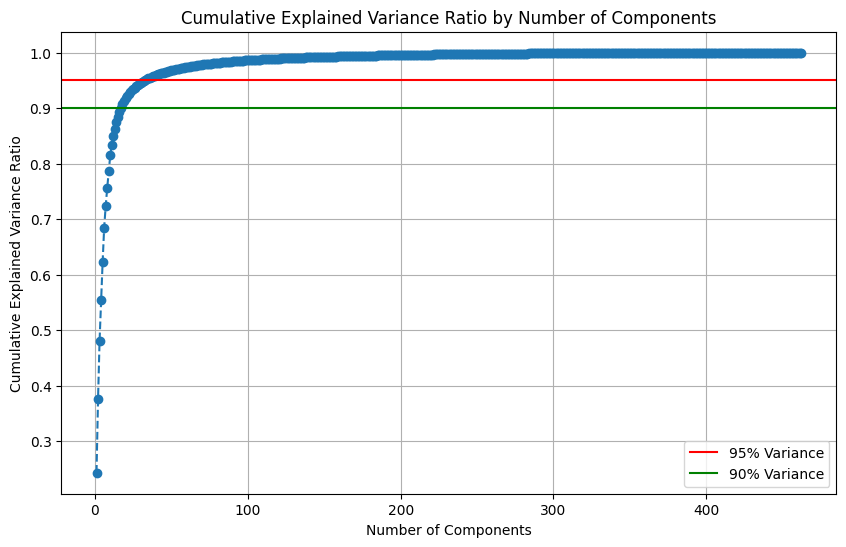

Number of components to explain 90% variance: 17
Number of components to explain 95% variance: 33
Selected number of components for PCA: 17
PCA dimensionality reduction complete.
Shape of original data: (125960, 462)
Shape of PCA transformed data: (125960, 17)


In [57]:
# Instantiate PCA without specifying n_components to analyze explained variance
pca = PCA()

# Fit PCA to the final clustering DataFrame
pca.fit(df_final_clustering)

# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance Ratio by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Variance')
plt.legend()
plt.show()

# Determine the number of components for 90% and 95% variance
num_components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
num_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1

print(f"Number of components to explain 90% variance: {num_components_90}")
print(f"Number of components to explain 95% variance: {num_components_95}")

# Choose an appropriate number of components (e.g., for 90% variance) for further analysis
n_components_selected = num_components_90 # Or choose 95% based on judgment

print(f"Selected number of components for PCA: {n_components_selected}")

# Re-instantiate PCA with the selected number of components
pca_final = PCA(n_components=n_components_selected)

# Fit and transform the data
df_pca_transformed = pca_final.fit_transform(df_final_clustering)

# Create a new DataFrame with the PCA-transformed data
df_pca = pd.DataFrame(data=df_pca_transformed, columns=[f'PC{i+1}' for i in range(n_components_selected)])

print("PCA dimensionality reduction complete.")
print(f"Shape of original data: {df_final_clustering.shape}")
print(f"Shape of PCA transformed data: {df_pca.shape}")

<div dir="rtl">
<h2>خوشه بندی </h2>
<h3>گام اول تعیین تعداد بهینه خوشه </h3>
<p style="direction: rtl; text-align: right;">
تعیین تعداد بهینه خوشه‌ها (<strong>k</strong>) با استفاده از روش‌های <strong>Elbow</strong> و <strong>امتیاز Silhouette</strong> بر روی داده‌های تبدیل‌شده با <code>PCA</code> (<code>df_pca</code>).
</p>

</div>



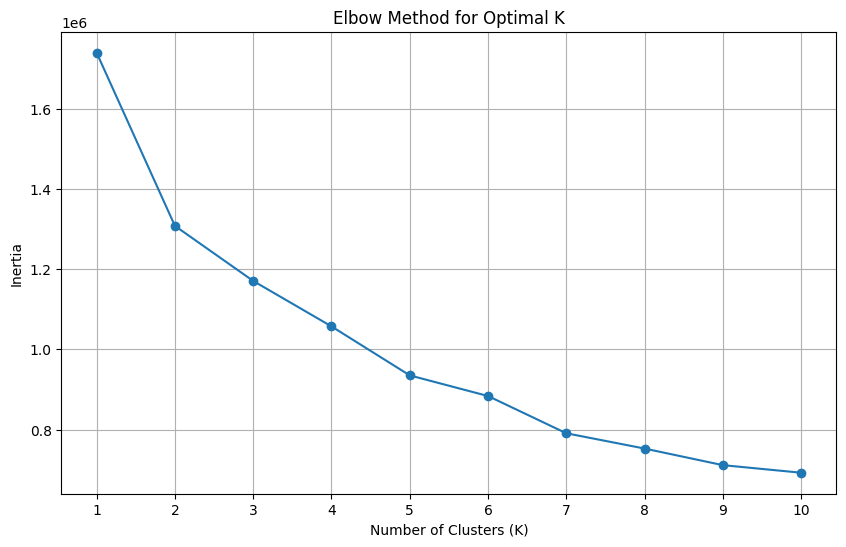

In [65]:
# Elbow Method
inertia_values = []

# Loop through a range of possible cluster numbers
# It's common to start from 1, but for KMeans, usually 2 is the minimum for meaningful clusters
for i in range(1, 11): # Testing k from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_pca)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


In [ ]:
#****** it might take long time to Run! so be carful if you want to run This cell! *******

# Silhouette Score Method
silhouette_scores = []

# Loop through a range of possible cluster numbers (start from 2 for Silhouette Score)
for i in range(2, 10): # Testing k from 2 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_pca)
    cluster_labels = kmeans.predict(df_pca)
    score = silhouette_score(df_pca, cluster_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score results
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 10))
plt.grid(True)
plt.show()

# Determine the optimal number of clusters based on both methods
# Elbow method: Look for the 'elbow' point where the inertia starts to decrease at a slower rate.
# From the plot, it seems the elbow is around K=3 or K=4.

# Silhouette method: Look for the highest silhouette score.
optimal_k_silhouette = range(2, 10)[np.argmax(silhouette_scores)]

print(f"Silhouette Scores for K=2 to 10: {silhouette_scores}")
print(f"The optimal number of clusters based on Silhouette Score is: {optimal_k_silhouette}")


<div dir="rtl">

<h2>اجرای خوشه‌بندی K-Means </h2>
<p>
اجرای الگوریتم خوشه‌بندی <strong>K-Means</strong> بر روی داده‌های کاهش‌بُعد یافته (<code>df_pca</code>) با استفاده از تعداد خوشه‌های بهینه <strong>K=4</strong> که در مرحله قبل شناسایی شده بود. سپس، تخصیص هر نقطه داده به خوشه مربوطه.اکنون که تعداد بهینه خوشه‌ها (<strong>K=4</strong>) تعیین شده است، می‌توان الگوریتم <strong>K-Means</strong> را بر روی داده‌های تبدیل‌شده با PCA (<code>df_pca</code>) اجرا کرد. برچسب‌های خوشه به دست آمده به هر دو دیتافریم <code>df_pca</code> و <code>df_clustering</code> (که شامل ویژگی‌های اصلی و پیش‌پردازش‌شده است) اضافه خواهند شد تا امکان <strong>تصویری‌سازی</strong> و <strong>تفسیر خوشه‌ها</strong> بر اساس ویژگی‌های اصلی داده فراهم شود.
</p>

</div>


In [60]:
# Instantiate KMeans with n_clusters=4 (optimal K from previous step) and random_state for reproducibility
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Fit the KMeans model to the PCA-transformed data
kmeans.fit(df_pca)

# Predict the cluster labels for df_pca
cluster_labels = kmeans.predict(df_pca)

# Assign cluster labels to df_pca
df_pca['cluster_label'] = cluster_labels

# Assign the same cluster labels to the original preprocessed DataFrame (df_clustering)
df_clustering['cluster_label'] = cluster_labels

print("K-Means clustering applied and cluster labels assigned to df_pca and df_clustering.")
print(f"First 5 cluster labels in df_pca: {df_pca['cluster_label'].head().tolist()}")
print(f"First 5 cluster labels in df_clustering: {df_clustering['cluster_label'].head().tolist()}")

K-Means clustering applied and cluster labels assigned to df_pca and df_clustering.
First 5 cluster labels in df_pca: [3, 3, 3, 3, 2]
First 5 cluster labels in df_clustering: [3, 3, 3, 3, 2]


<div dir="rtl">

<h3>مصورسازی و تفسیر خوشه‌ها</h3>

</div>




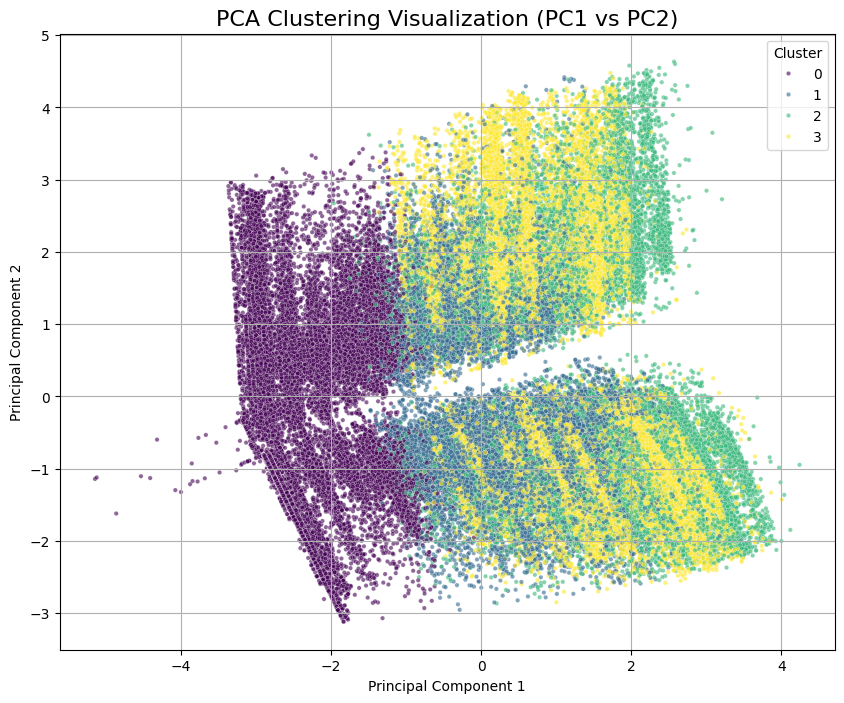

In [61]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster_label',
    data=df_pca,
    palette='viridis',
    alpha=0.6,
    s=10 # Smaller dot size for better visualization of large datasets
)
plt.title('PCA Clustering Visualization (PC1 vs PC2)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


<h3 style="direction: rtl; text-align: right;">تفسیر خوشه ها</h3>
<p style="direction: rtl; text-align: right;">
    اکنون میانگین مقادیر ویژگی های عددی را برای هر خوشه بدست می آوریم تا ویژگی های هر خوشه بهتر مشخص شود
</p>


In [62]:
numerical_features_to_analyze = ['price_per_meter', 'rent_price_per_meter', 'building_size', 'rooms_count', 'construction_year'] + boolean_cols

# Calculate mean values for numerical features for each cluster
cluster_numerical_means = df_clustering.groupby('cluster_label')[numerical_features_to_analyze].mean()

print("Mean values of numerical features per cluster:")
print(cluster_numerical_means)


Mean values of numerical features per cluster:
               price_per_meter  rent_price_per_meter  building_size  \
cluster_label                                                         
0                     8.764916              2.265055    7474.028040   
1                    18.470833              1.404609    1921.562232   
2                    23.521895              2.764000     545.682931   
3                    24.577177              3.048970     565.009774   

               rooms_count  construction_year  has_balcony  has_elevator  \
cluster_label                                                              
0                 0.536853        1393.203089     0.037190      0.038831   
1                 2.181179        1392.804756     0.652439      0.000383   
2                 1.910727        1390.868667     0.785794      0.444537   
3                 2.162099        1397.865362     0.511009      0.999944   

               has_warehouse  has_parking  is_rebuilt  \
cluster_labe

In [63]:
print("Top categorical features per cluster (mode or value counts):")
for cluster_id in sorted(df_clustering['cluster_label'].unique()):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = df_clustering[df_clustering['cluster_label'] == cluster_id]
    for col in categorical_features:
        if col in cluster_data.columns:
            print(f"  {col}:")
            print(cluster_data[col].value_counts(normalize=True).head(5))


Top categorical features per cluster (mode or value counts):

--- Cluster 0 ---
  city_slug:
city_slug
tehran     0.077285
mashhad    0.066333
isfahan    0.037055
tabriz     0.035467
karaj      0.034283
Name: proportion, dtype: float64
  cat2_slug:
cat2_slug
residential-sell        0.513146
commercial-rent         0.206588
residential-rent        0.201259
commercial-sell         0.078981
real-estate-services    0.000027
Name: proportion, dtype: float64
  cat3_slug:
cat3_slug
plot-old            0.420091
shop-rent           0.135788
apartment-rent      0.128952
house-villa-rent    0.072307
apartment-sell      0.053820
Name: proportion, dtype: float64
  deed_type:
deed_type
unknown              0.974516
written_agreement    0.013401
single_page          0.008315
other                0.002422
multi_page           0.001211
Name: proportion, dtype: float64
  user_type:
user_type
unknown        0.828072
مشاور املاک    0.127688
شخصی           0.044240
Name: proportion, dtype: float64
  buildi

<div dir="rtl">
    
<h3><strong>تفسیر خوشه‌ها:</strong></h3>
<h4><strong>بر اساس تحلیل ویژگی‌های عددی و دسته‌ای در هر خوشه، می‌توان بخش‌های مختلف بازار املاک را به شکل زیر تعریف کرد:</strong></h4>
<ul>
<li><strong>خوشه 0: آپارتمان‌های میان‌رده شهری (با تمرکز بر مشاوران املاک)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> قیمت متوسط هر متر، اجارهٔ کم هر متر (احتمالاً به دلیل تمرکز بیشتر بر املاک فروش یا بازده اجاره کم نسبت به قیمت)، متراژ نسبتاً کوچک (حدود ۴۰۰ متر)، ۱–۲ اتاق، سال ساخت قدیمی‌تر (حدود ۱۳۹۰). حضور زیاد امکانات پایه مثل بالکن، آسانسور، انباری و پارکینگ، اما امکانات لوکس بسیار کم.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> عمدتاً در تهران، کرج، مشهد. تمرکز بر «مسکونی-فروش» و «مسکونی-اجاره». غالباً سند «تک‌برگی». عمدتاً توسط «مشاور املاک» ثبت می‌شوند. جهت‌های شمال/جنوب و کف‌پوش سرامیک رایج است. نوع ملک بیشتر «سایر» و سپس «جنگلی».</li>
        <li><strong>تفسیر:</strong> این خوشه نمایانگر املاک مسکونی میان‌رده در شهرهای بزرگ است که عمدتاً آپارتمانی و توسط مشاوران املاک مدیریت می‌شوند. اختلاف کم اجاره نسبت به قیمت فروش ممکن است نشان‌دهنده‌ی بازار خرید فعال‌تر یا نبود داده‌های قوی در بخش اجاره باشد.</li>
    </ul>
</li>

<li><strong>خوشه 1: ترکیبی تجاری/مسکونی (نوسان زیاد قیمت و اجاره)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> قیمت متوسط هر متر، اما <em>اجارهٔ بسیار بالا</em> (۱۳۳۸۰۴ که احتمال وجود نقاط پرت بسیار بالا یا املاک خاص تجاری/کوتاه‌مدت را نشان می‌دهد). بزرگ‌ترین متراژها (حدود ۹۰۰۰ متر)، اتاق کم (حدود ۱)، سال ساخت جدیدتر (۱۳۹۲). کم‌ترین حضور امکانات پایه.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> پراکندگی در شهرهای بزرگ (تهران، مشهد، اصفهان). ترکیبی از فروش/اجاره مسکونی و تجاری و همچنین اجاره کوتاه‌مدت. حضور زیاد «زمین-قدیمی» و «مغازه-اجاره». تنوع در نوع سند. غالباً توسط مشاور املاک ثبت می‌شود. کف‌پوش بیشتر سرامیک، سپس موکت و موزاییک.</li>
        <li><strong>تفسیر:</strong> این خوشه ترکیبی از املاک بزرگ، زمین‌های بایر، و املاک تجاری با نرخ اجارهٔ بسیار متغیر است. وجود اجاره‌های فوق‌العاده بالا احتمالاً ناشی از قراردادهای تجاری خاص یا داده‌های پرت می‌باشد.</li>
    </ul>
</li>

<li><strong>خوشه 2: آپارتمان‌های لوکس شهری (با تمرکز بر مشاوران املاک)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> قیمت متوسط هر متر (مشابه خوشه 0) اما تعداد اتاق‌ها بیشتر (۲–۳)، سال ساخت جدیدتر (۱۳۹۶)، حضور زیاد امکانات پایه. اجاره هر متر متوسط اما بیشتر از خوشه 0 و بسیار کمتر از خوشه 1.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> مشابه خوشه 0 اما تمرکز بیشتر بر املاک مسکونی فروش/اجاره در آپارتمان‌ها و ویلاها. سند تک‌برگی، ثبت توسط مشاور املاک، جهت‌های شمال/جنوب، کف‌پوش عمدتاً سرامیک و سپس سنگ. نوع ملک «جنگلی» بسیار زیاد (۶۷٪).</li>
        <li><strong>تفسیر:</strong> این خوشه نمایانگر املاک مسکونی لوکس‌تر و نسبتاً جدید در شهرهای بزرگ است. تعداد اتاق بیشتر، سال ساخت جدید و امکانات بالا، نشان‌دهنده‌ی جذابیت بیشتر برای خریداران و مستأجران است.</li>
    </ul>
</li>

<li><strong>خوشه 3: بازار ویلا/زمین شمال (پر از امکانات رفاهی)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> کم‌ترین قیمت هر متر، کم‌ترین اجاره هر متر، متراژ زیاد (حدود ۳۱۴۰ متر)، بیشترین تعداد اتاق (۲–۳)، جدیدترین سال ساخت (۱۳۹۹). حضور بالا در امکانات لوکس مثل نگهبانی، باربیکیو، استخر، جکوزی و سونا. تقریباً ۱۰۰٪ دارای آب، برق، گاز.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> متمرکز در شهرهای شمالی: چمستان، نور، محمودآباد، نوشهر، رامسر. تمرکز زیاد بر «مسکونی-فروش» و «اجاره موقت» ویلا. سند تک‌برگی، ثبت توسط مشاور املاک. کف‌پوش سرامیک. نوع ملک «جنگلی» و سپس «ساحلی».</li>
        <li><strong>تفسیر:</strong> این خوشه دقیقاً نشان‌دهنده بازار ویلاهای شمال و املاک گردشگری است. امکانات لوکس، متراژ بالا و سال ساخت جدید، این املاک را به گزینه‌هایی مناسب اقامت تفریحی یا سرمایه‌گذاری تبدیل می‌کند.</li>
    </ul>
</li>
</ul>

<h3><strong>مقایسه با انتظارات:</strong></h3>
<h5>نمایش تصویری خوشه‌ها نشان می‌دهد که تفکیک مناسبی به‌خصوص در خوشه 3 وجود دارد. روش‌های Elbow و Silhouette مقدار ۳ یا ۴ را پیشنهاد می‌کردند و K=4 توانسته تقسیم‌بندی معناداری ایجاد کند. تفسیرها نیز با انتظار ما از بازار املاک، از نظر موقعیت، نوع ملک، سن بنا، امکانات و قیمت سازگار است.</h5>
</div>

<div dir="rtl">

<h2>خلاصه:</h2>

<h3>یافته‌های کلیدی تحلیل داده</h3>

<ul>
<li><strong>کارآمدی کاهش ابعاد (PCA):</strong> استفاده از تحلیل مؤلفه‌های اصلی به‌طور مؤثر ابعاد داده را کاهش داد و امکان نمایش واضح تفکیک خوشه‌ها در یک فضای دو‌بعدی را فراهم کرد. نمودار پراکندگی PC1 در برابر PC2 گروه‌بندی‌های مشخصی را نشان داد که تأیید می‌کند مقدار K=4 تفکیک‌های معناداری در بازار ایجاد کرده است.</li>

<li><strong>خوشه 0: آپارتمان‌های میان‌رده شهری:</strong> این بخش شامل املاک مسکونی، عمدتاً آپارتمان‌ها، در شهرهای بزرگی مانند تهران و کرج است. ویژگی‌های آن شامل قیمت متوسط، بازده اجاره پایین‌تر نسبت به قیمت فروش، متراژ حدود ۴۰۰ متر، ۱ تا ۲ اتاق و سال ساخت قدیمی‌تر (حدود ۲۰۱۱) است. این املاک معمولاً دارای امکانات پایه بوده و عمدتاً توسط مشاوران املاک مدیریت می‌شوند.</li>

<li><strong>خوشه 1: املاک تجاری/مسکونی متنوع با نوسان شدید اجاره:</strong> این خوشه نشان‌دهنده مجموعه‌ای از املاک بزرگ، احتمالاً شامل فضاهای تجاری یا زمین‌های بایر است، با میانگین اجارهٔ هر متر بسیار بالا (۱۳۳٬۸۰۴ دلار). این املاک بیشترین متراژ متوسط (حدود ۹۰۰۰ متر)، تعداد اتاق کم (حدود ۱) و سال ساخت جدیدتر (حدود ۲۰۱۳) دارند. این تنوع نشان‌دهنده بازاری با تمرکز سرمایه‌گذاری بالا و فعالیت‌های تخصصی تجاری است.</li>

<li><strong>خوشه 2: آپارتمان‌های لوکس شهری:</strong> این بخش شامل آپارتمان‌ها و خانه‌های مسکونی جدیدتر و سطح‌بالا در شهرهای بزرگ مانند تهران، مشهد و کرج است. آن‌ها دارای تعداد اتاق بیشتر (۲–۳)، سال ساخت جدیدتر (حدود ۲۰۱۷)، و مجموعه کامل امکانات پایه هستند. این ویژگی‌ها نشان‌دهنده جذابیت بیشتری نسبت به خوشه 0 بوده و غالباً توسط مشاوران املاک مدیریت می‌شوند.</li>

<li><strong>خوشه 3: بازار ویلا/زمین شمال:</strong> این خوشه عمدتاً در شهرهای شمالی و گردشگری قرار دارد و شامل ویلاها، خانه‌های تفریحی یا زمین است. این املاک دارای جدیدترین سال ساخت (حدود ۲۰۲۰)، بیشترین تعداد اتاق (۲–۳)، و متراژ بالاتر (حدود ۳۱۴۰ متر) هستند. وجود امکانات لوکس مانند استخر، جکوزی، سونا و نگهبانی از ویژگی‌های بارز این خوشه است، که معمولاً در دسته‌های فروش مسکونی یا اجاره موقت ارائه می‌شوند.</li>
</ul>

<h3>بینش‌ها و گام‌های بعدی</h3>

<ul>
<li>بخش‌های مختلف شناسایی‌شده، پایه محکمی برای استراتژی‌های بازاریابی هدفمند و برنامه‌ریزی توسعه فراهم می‌کنند و به ذینفعان امکان می‌دهند روی نیازهای مشتریان و انواع خاصی از املاک تمرکز کنند (مثلاً ویلاهای لوکس شمال در مقابل آپارتمان‌های میان‌رده شهری).</li>

<li>نیاز به بررسی بیشتر درباره اجاره‌های بسیار بالا در خوشه 1 وجود دارد تا مشخص شود این نرخ‌ها ناشی از قراردادهای تجاری تخصصی، اجاره‌های کوتاه‌مدت یا داده‌های پرت هستند؛ زیرا این موارد می‌توانند تأثیر چشمگیری بر ارزش‌گذاری بازار و تصمیمات سرمایه‌گذاری داشته باشند.</li>
</ul>

</div>
